# Model Evaluation and Performance Analysis

This notebook evaluates the performance of the trained student face recognition model.

The evaluation process measures the model's ability to correctly identify individual students from unseen validation samples. Performance is analyzed using prediction outputs and confusion matrices.

Evaluation objectives:

* Load trained CNN model
* Generate predictions on validation data
* Compare predictions against ground truth labels
* Visualize classification performance
* Analyze strengths and weaknesses of the model

The results provide insight into the model's suitability for integration into future automated attendance systems.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from tqdm.notebook import tqdm

from training import predict

In [39]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


# Preparing and Loading Data

In [40]:
data_dir = os.path.join("data_p1", "data_undersampled", "train")
print("Data directory:", data_dir)

Data directory: data_p1\data_undersampled\train


In [41]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [42]:
transform = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.6665, 0.6047, 0.5631], std=[0.2257, 0.2515, 0.2687])
    ]
)

In [43]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataset

Dataset ImageFolder
    Number of datapoints: 1200
    Root location: data_p1\data_undersampled\train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.6665, 0.6047, 0.5631], std=[0.2257, 0.2515, 0.2687])
           )

In [44]:
classes = dataset.classes
classes

['abdulrahman', 'fatima', 'labaran', 'maryam', 'usman', 'zainab']

#### Train-Validation Split

In [45]:
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])

length_train = len(train_dataset)
length_val = len(val_dataset)
length_dataset = len(dataset)
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 80.0% of full data
Validation data is 20.0% of full data


In [46]:
g = torch.Generator()
g.manual_seed(42)

batch_size = 16
val_loader = DataLoader(val_dataset, batch_size=batch_size)

single_batch = next(iter(val_loader))[0]
print(f"Shape of one batch: {single_batch.shape}")

Shape of one batch: torch.Size([16, 3, 224, 224])


In [48]:
model = torch.load("model/JAYset_1.0.pth", weights_only=False)

In [49]:
probabilities = predict(model, val_loader, device)
predictions = torch.argmax(probabilities, dim=1)

predictions

Predicting:   0%|          | 0/15 [00:00<?, ?it/s]

tensor([3, 3, 0, 5, 4, 0, 4, 2, 1, 3, 2, 1, 3, 1, 4, 4, 4, 0, 4, 5, 0, 1, 5, 3,
        0, 2, 4, 1, 2, 5, 1, 1, 0, 2, 0, 5, 5, 4, 5, 4, 5, 3, 0, 0, 5, 5, 0, 5,
        5, 1, 3, 3, 5, 3, 3, 1, 5, 1, 5, 3, 1, 2, 4, 1, 0, 5, 4, 3, 0, 1, 5, 3,
        4, 5, 5, 1, 1, 0, 1, 4, 0, 1, 1, 5, 3, 3, 5, 0, 4, 4, 2, 3, 4, 5, 0, 1,
        3, 5, 5, 2, 1, 2, 1, 3, 2, 3, 5, 2, 5, 3, 4, 4, 1, 5, 4, 3, 2, 5, 4, 0,
        0, 0, 2, 0, 4, 1, 5, 3, 1, 3, 1, 3, 4, 0, 1, 1, 4, 2, 1, 0, 3, 0, 1, 0,
        1, 1, 2, 1, 5, 3, 3, 5, 2, 1, 0, 5, 5, 3, 3, 3, 3, 0, 0, 4, 3, 2, 1, 3,
        3, 2, 1, 0, 3, 4, 3, 4, 4, 0, 0, 0, 4, 0, 3, 0, 1, 0, 0, 5, 1, 4, 3, 5,
        1, 0, 1, 0, 3, 3, 5, 1, 2, 2, 1, 4, 4, 1, 3, 4, 2, 2, 0, 3, 0, 3, 4, 4,
        5, 3, 4, 5, 0, 1, 5, 1, 5, 3, 5, 1, 3, 0, 2, 0, 2, 2, 0, 1, 1, 4, 5, 5])

In [50]:
targets = []

for _, labels in tqdm(val_loader):
    targets.extend(labels.tolist())

  0%|          | 0/15 [00:00<?, ?it/s]

In [51]:
classes

['abdulrahman', 'fatima', 'labaran', 'maryam', 'usman', 'zainab']

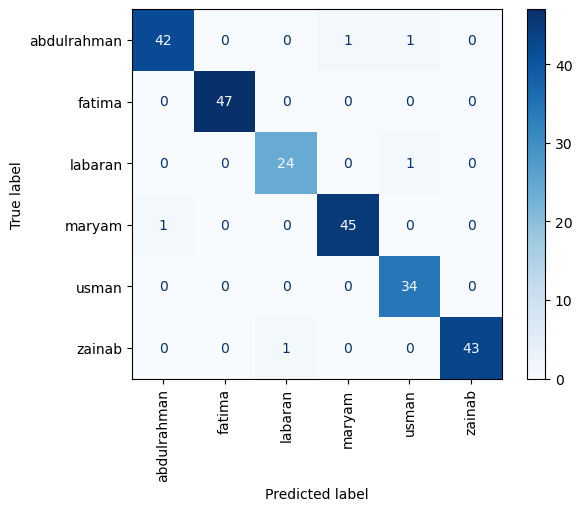

In [52]:
cm = confusion_matrix(targets, predictions.cpu())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.show();